# MES (Micro E-mini S&P 500) — MA crossover, Tradovate exchange

Mirrors `test_backtester.ipynb`'s MA-crossover setup, but trades **Micro ES futures**
through a simulated **Tradovate** exchange instead of spot ETH/USD through a crypto
exchange: real 1h OHLC pulled from this repo's Mongo/Timescale store (via the shared
`data_aggregator.mongo_timescale_aggregator` module) instead of a CSV, whole-contract
position sizing, tick-based slippage + per-contract fees, and a Tradeify-style
EOD-trailing drawdown risk middleware.

**Strategy**: a single KAMA(fast)/SMA(slow) crossover -- the winner of the four-way
indicator-family comparison (KAMA, EMA, HMA, DEMA, each fast-line paired against a
plain SMA slow line) run in `notebooks/vectorized_backtest_mes_tradovate.ipynb`,
selected by a trade-level Sharpe lower bound rather than raw return (see that
notebook's "Methodology" and "Final pick" cells for the full reasoning + honest
caveats about how much confidence that pick actually supports). Only 2 indicators
(one KAMA, one SMA) feed a single strategy here, run through the full event-driven
engine: real order fills, margin, whole-contract sizing, and the drawdown middleware,
none of which the vectorized notebook models. Same `DATE_FROM`/`DATE_TO` window as
that notebook so the two are comparable. Results here will still differ from the
vectorized numbers -- that's expected, not a bug, since whole-contract sizing/margin
are modeled for real here instead of as a frictionless percentage-return
approximation.

**Costs, now researched** (`PROP_FIRM_PLAN.md`, `OPTIMIZATION_RESEARCH_PLAN.md`): MES
tick_size=0.25 index points ($1.25/tick, CME spec) and a $0.91/side commission (half
of Tradeify's $1.82 MES round-turn) are set directly on `TRADOVATE_FUTURES["MES"]` in
`exchange_config.py` -- the earlier `slippage_ticks=0`/`default_fee_per_contract=0.0`
placeholder overrides are gone. The drawdown middleware below also uses Tradeify's
real $50k-Growth-account number (4%, not this middleware's generic 5% default).

In [1]:
import json
import os

import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import MaCrossoverStrategy, StrategyDirection
from data_aggregator.mongo_timescale_aggregator import fetch_market_data

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/tradovate_ma_crossover/MES


In [2]:

# Instantiate markets class
market = Market()

# ALL INTERVALS SHOULD BE THE SAME!!
INTERVAL = 1
UNIT_OF_TIME = "hour"

DISPLAY_SYMBOL = "MES"       # bare symbol, as registered in Mongo `instruments`
SYMBOL = "MES/USD"           # backtester-internal symbol (asset/quote)
SOURCE = "ib"                # Interactive Brokers continuous futures contract
RESOLUTION = "1_hour"

# Same window as notebooks/vectorized_backtest_mes_tradovate.ipynb, for comparability.
DATE_FROM = "2019-10-01"
DATE_TO = "2026-06-01"

# Winner of the 4-indicator-family comparison in vectorized_backtest_mes_tradovate.ipynb
# (KAMA/EMA/HMA/DEMA, each vs. a plain SMA slow line, ranked by trade-level Sharpe
# lower bound with real Tradeify costs applied): KAMA(fast)/SMA(slow), long_len=42,
# short_len=26. KAMA's own fast/slow EMA constants are left at Kaufman's defaults
# (2, 30) -- not re-tuned, see that notebook's intro for why stacking another grid on
# top of the length search was deliberately skipped this pass.
KAMA_FAST_LEN = 26
KAMA_EMA_FAST = 2
KAMA_EMA_SLOW = 30
KAMA_SMA_SLOW = 42

ohlc = fetch_market_data(source=SOURCE, display_symbol=DISPLAY_SYMBOL, resolution=RESOLUTION)
ohlc = ohlc.loc[DATE_FROM:DATE_TO]

market.add_market(
    symbol=SYMBOL,
    df=ohlc
    )

# --- KAMA(fast)/SMA(slow) crossover indicators -- only 2, one per side of the
# crossover, instead of also running a separate plain-SMA/SMA crossover alongside it.
KAMA_INDICATOR_NAME = 'kama'
SMA_INDICATOR_NAME = 'sma'
market.add_indicator(
    symbol=SYMBOL,
    interval=INTERVAL,
    unit_of_time=UNIT_OF_TIME,
    indicator_name=f"{KAMA_INDICATOR_NAME}_{KAMA_FAST_LEN}",
    df=Indicators.kama(ohlc, length=KAMA_FAST_LEN, fast=KAMA_EMA_FAST, slow=KAMA_EMA_SLOW)
)
market.add_indicator(
    symbol=SYMBOL,
    interval=INTERVAL,
    unit_of_time=UNIT_OF_TIME,
    indicator_name=f"{SMA_INDICATOR_NAME}_{KAMA_SMA_SLOW}",
    df=Indicators.sma(ohlc, KAMA_SMA_SLOW)
)

market.compile()

{Timestamp('2025-07-08 14:42:16.999000'): {'num': 0,
  'time_open': Timestamp('2025-07-08 13:42:17'),
  'time_close': Timestamp('2025-07-08 14:42:16.999000'),
  'MES/USD': {'open': 6489.25,
   'high': 6495.5,
   'low': 6484.75,
   'close': 6484.75,
   'volume': 47036.0,
   'indicators': {'kama_26': nan, 'sma_42': nan}}},
 Timestamp('2025-07-08 14:59:59.999000'): {'num': 1,
  'time_open': Timestamp('2025-07-08 14:00:00'),
  'time_close': Timestamp('2025-07-08 14:59:59.999000'),
  'MES/USD': {'open': 6485.25,
   'high': 6494.0,
   'low': 6472.75,
   'close': 6482.75,
   'volume': 208566.0,
   'indicators': {'kama_26': nan, 'sma_42': nan}}},
 Timestamp('2025-07-08 15:59:59.999000'): {'num': 2,
  'time_open': Timestamp('2025-07-08 15:00:00'),
  'time_close': Timestamp('2025-07-08 15:59:59.999000'),
  'MES/USD': {'open': 6482.75,
   'high': 6490.75,
   'low': 6475.0,
   'close': 6489.25,
   'volume': 97794.0,
   'indicators': {'kama_26': nan, 'sma_42': nan}}},
 Timestamp('2025-07-08 16:59:5

In [3]:

# single KAMA(fast)/SMA(slow) crossover strategy, full weight -- see
# vectorized_backtest_mes_tradovate.ipynb for how these parameters were picked.
portfolio = Portfolio(weighted_strategies=[
    WeightedStrategy(
        weight=1.0,
        strategy=MaCrossoverStrategy(
            key="KAMA_26_SMA_42_MES",
            market=market,
            symbol=SYMBOL,
            direction=StrategyDirection.long,
            fast_indicator_key=f"{KAMA_INDICATOR_NAME}_{KAMA_FAST_LEN}",
            slow_indicator_key=f"{SMA_INDICATOR_NAME}_{KAMA_SMA_SLOW}",
            sl_percent=0.3,
            tp_percent=0.6,
            sl_enabled=True,
            tp_enabled=True,
        ),
    ),
], output_scale=1)

print("Portfolio is ready!")


Portfolio is ready!


In [4]:

# Tradovate per-symbol config: point value / tick size / min size-step / fees.
# MES now has a real tick_size (0.25 pts) and fee_per_contract_override ($0.91/side)
# set directly on TRADOVATE_FUTURES in exchange_config.py -- no override needed here
# anymore (see PROP_FIRM_PLAN.md for the research).
symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)

# instantiate exchange -- futures, point-value/tick-based math via symbol_config_provider
# (slippage/maker_fee/taker_fee below are unused once symbol_config_provider is set, but
# still required constructor args).
exchange = Exchange(
            market=market,
            slippage=0.0,
            maker_fee=0.0,
            taker_fee=0.0,
            market_type=MarketType.future,
            max_leverage=10,  # NOTE: this system doesn't model Tradovate's real per-symbol
                               # exchange-set margin schedule yet -- max_leverage is a stand-in.
            margin_allocation_type=MarginAllocationType.cross,
            symbol_config_provider=symbol_config_provider,
        )


In [5]:

# instantiate reporter
# periods_per_year=252: real trading-days/year convention for futures (not 365,
# which is only correct for a 24/7 crypto market -- see PerformanceAnalyzer's own
# docstring). Using the wrong constant here previously inflated every Sharpe/
# Sortino/annualized-volatility number in this pipeline by sqrt(365/252) =~ 1.20
# (~20%) versus the correct figure -- CAGR/Calmar/max_drawdown/net_return are
# unaffected since they don't depend on periods_per_year.
reporter = PerformanceAnalyzer(market=market,
                    exchange=exchange,
                    portfolio=portfolio,
                    benchmark_symbols=[SYMBOL],
                    periods_per_year=252)


Candles Processed:  5312
Account failed (drawdown breach):  False
Drawdown floor locked (reached profit buffer):  True


metric,algo,MES/USD,description
sharpe_ratio,1.3484,1.1979,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,2.0107,1.7736,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,4.8117,11.2466,How much the equity curve swings per year. Lower = smoother.
cagr_percent,9.6685,20.4368,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,2.9352,2.0631,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,2.6251,1.8361,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-3.2940,-9.9056,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,126,72,How long it took to recover the loss. Shorter is better.
ulcer_index,1.3243,2.3811,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-0.4409,-1.0687,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


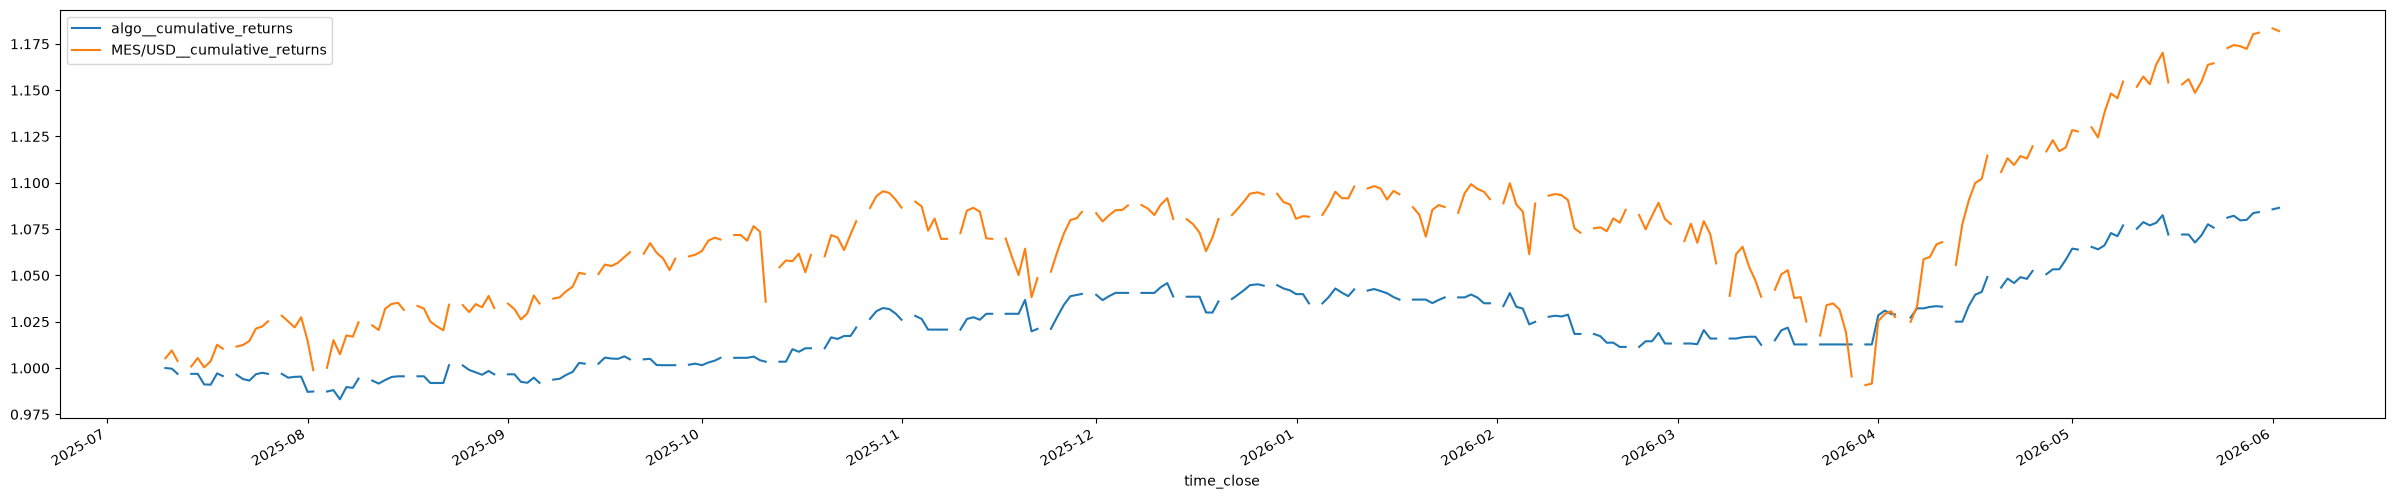

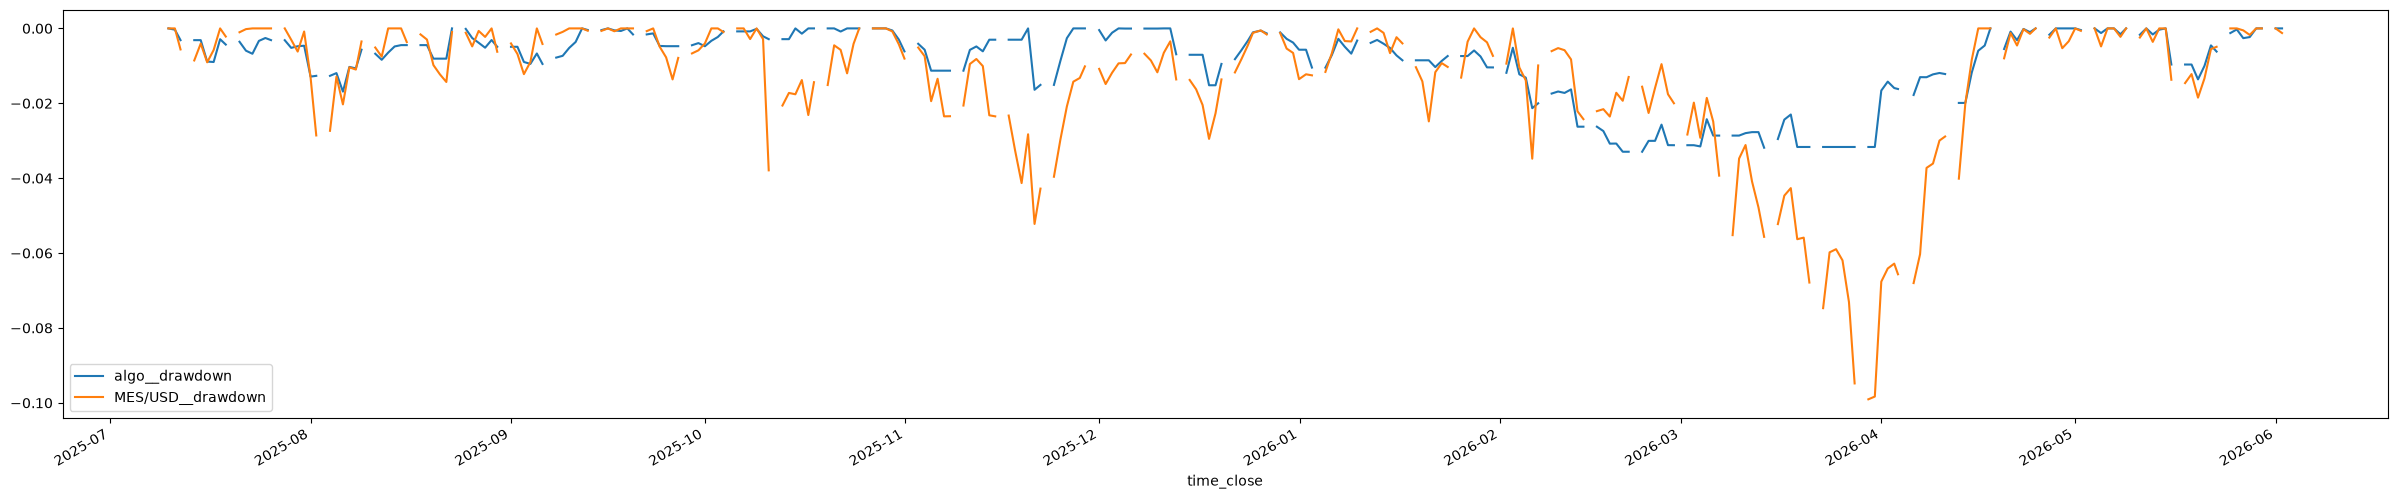

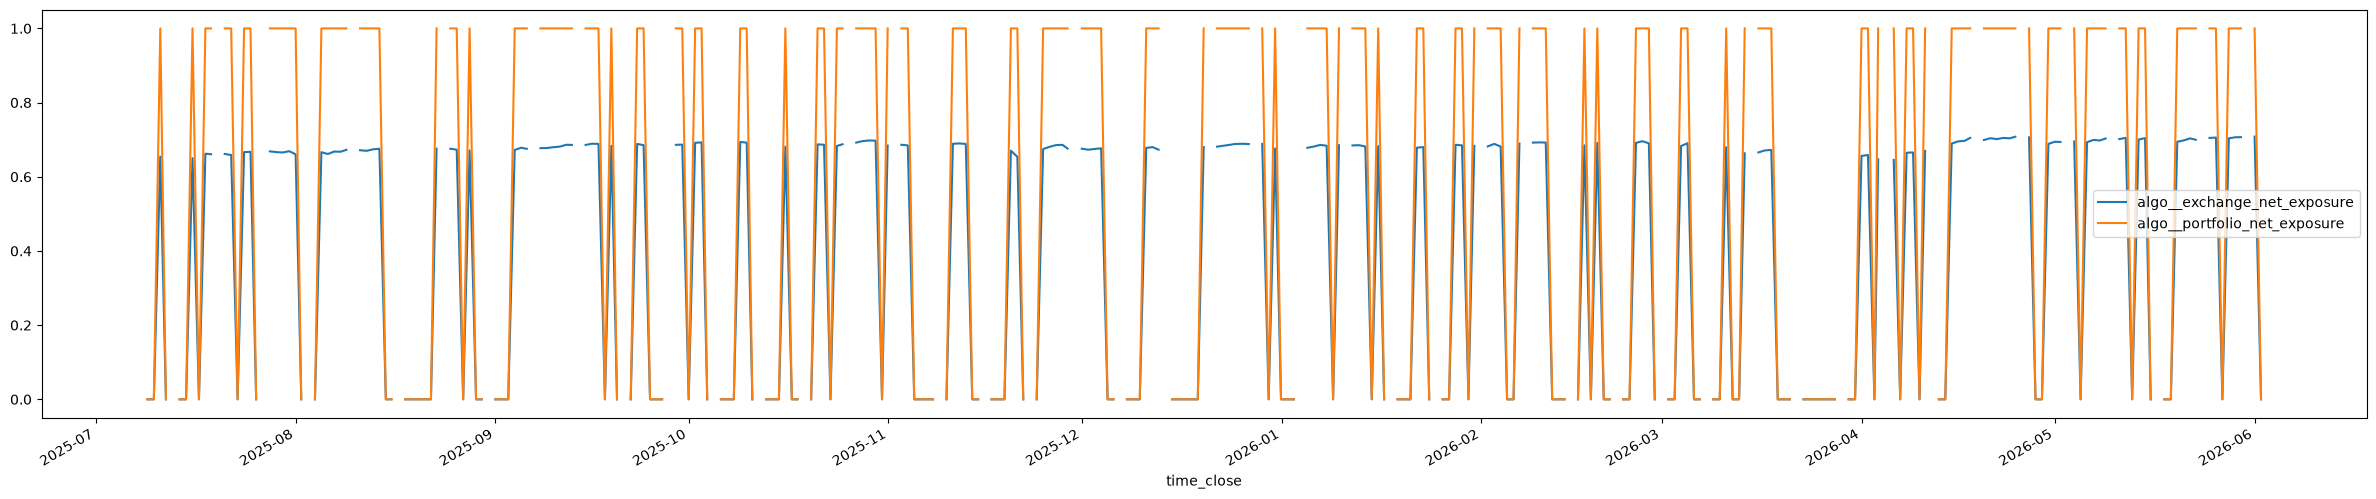

In [6]:

# run only one next step
market.reset()

# Tradeify Growth $50k account: $2,000 (4%) EOD-trailing drawdown, permanently halts
# trading (account_failed) once breached -- see middleware.py / PROP_FIRM_PLAN.md.
# Now also models Tradeify's real lock-once-reached mechanic: the trailing floor
# freezes permanently at initial_balance + $100 the first time EOD balance reaches
# initial_balance * (1 + drawdown_percent) + $100 (e.g. $52,100 for this account),
# rather than continuing to trail upward forever past that point.
drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.04)
# Tradeify's real $1,250/day soft daily-loss pause on a $50k account (2.5% of
# balance): flattens and halts for the rest of the trading day, then resumes
# normally the next day (unlike the drawdown middleware's permanent halt).
# Previously not modeled at all in this pipeline despite being a real,
# already-documented Tradeify rule (PROP_FIRM_PLAN.md).
daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.025)

backtest = Backtester(
    market=market,
    portfolio=portfolio,
    exchange=exchange,
    reporter=reporter,
    middlewares=[daily_loss_middleware, drawdown_middleware],
)
# deposit prop-firm-sized funds so we can trade
backtest.exchange.transactions.add_deposit(asset="USD", volume=50000)
backtest.run_all()

# Print Report
print("Candles Processed: ", backtest.market.current['num'])
print("Account failed (drawdown breach): ", drawdown_middleware.account_failed)
print("Drawdown floor locked (reached profit buffer): ", drawdown_middleware.locked)
# formatted HTML table (description column + color-coded cells) instead of the raw
# numeric DataFrame -- see backtester.performance.report_html for the per-metric rules.
display(HTML(backtest.reporter.summary_html_table()))

if backtest.reporter.merged is not None:
    # Print a chart to compare the returns
    backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns"
        ], figsize=(30,6))

    backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown"
        ], figsize=(30,6))

    backtest.reporter.merged.plot(x="time_close", y=[
        "algo__exchange_net_exposure",
        "algo__portfolio_net_exposure"
        ], figsize=(30,6))


In [7]:
# market.merged
pd.DataFrame(backtest.exchange.get_logs())


,time,message
0,2025-07-08 14:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
1,2025-07-10 17:59:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
2,2025-07-11 02:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
3,2025-07-15 01:59:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
4,2025-07-16 07:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
...,...,...
128,2026-05-26 15:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
129,2026-05-27 16:59:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
130,2026-05-28 14:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
131,2026-05-28 18:59:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...


In [8]:
# get dataframe with all the trades that were executed
def _trade_to_dict(trade):
    d = trade.__dict__.copy()
    for k, v in d.items():
        if hasattr(v, "value"):
            d[k] = v.value
    return d

pd.DataFrame([_trade_to_dict(t) for t in backtest.reporter.trades])


,symbol,side,time_open,time_close,open_price,close_price,close_reason,pnl,result,holding_period,risk_percent
0,MES/USD,long,1752170399999000000,1752202799999000000,6545.50,6515.00,signal,-0.004660,loser,32400000000000,0.3
1,MES/USD,long,1752544799999000000,1752652799999000000,6540.00,6482.50,signal,-0.008792,loser,108000000000000,0.3
2,MES/USD,long,1752721199999000000,1753102799999000000,6501.50,6555.75,signal,0.008344,winner,381600000000000,0.3
3,MES/USD,long,1753113599999000000,1753207199999000000,6584.25,6553.75,signal,-0.004632,loser,93600000000000,0.3
4,MES/USD,long,1753268399999000000,1753433999999000000,6584.25,6621.50,signal,0.005657,winner,165600000000000,0.3
...,...,...,...,...,...,...,...,...,...,...,...
61,MES/USD,long,1778695199999000000,1778878799999000000,7529.00,7480.25,signal,-0.006475,loser,183600000000000,0.3
62,MES/USD,long,1779152399999000000,1779433199999000000,7486.50,7552.00,signal,0.008749,winner,280800000000000,0.3
63,MES/USD,long,1779465599999000000,1779811199999000000,7573.75,7586.25,signal,0.001650,winner,345600000000000,0.3
64,MES/USD,long,1779901199999000000,1779980399999000000,7594.25,7626.25,signal,0.004214,winner,79200000000000,0.3
